# CocoChorales pYIN-HMM parameter sweeps

This notebook is a launcher and results viewer; all expensive work runs in external, process-parallel scripts.

**Terminology:** `attune-uniform` names only Attune's observation-likelihood formulation. An **automatic winner** is the complete parameter tuple selected across all sampled tracks: observation mode, `max_jump_bins`, `switch_prob`, and `yin_trust`. The pYIN paper's transition constants are defined per frame. Since Attune's hop is half as long, the time-scaled constants are the literal paper baseline on Attune's frame grid; no separate unscaled-paper baseline is needed.

The first result directory retains the compact observation-formulation comparison. The second sweep fixes the winning `attune-uniform` observation mode and explores a denser 224-point grid over the other three parameters. Statistics combine all 48 stems, first averaging within each `(ensemble, instrument)` stratum so every represented family receives equal weight.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / 'app.py').is_file() and (path / 'benchmarks').is_dir()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from benchmarks.modules.pitch.PitchHMMParamSweep import (
    ATTUNE_OBSERVATION,
    DEFAULT_OUTPUT_DIR,
    PARAM_COLUMNS,
    ParameterAxes,
    SweepOptions,
    load_results,
    paper_parameters,
    parameter_grid,
    production_parameters,
    select_sample,
)

COMPACT_OUTPUT_DIR = DEFAULT_OUTPUT_DIR
ATTUNE_OUTPUT_DIR = DEFAULT_OUTPUT_DIR / 'attune_grid'
CACHE_REFRESH_OUTPUT_DIR = DEFAULT_OUTPUT_DIR / 'cache_refresh'
SWEEP_RUNNER = REPO_ROOT / 'benchmarks' / 'sweeps' / 'scripts' / 'pitch_hmm_param_sweep.py'
CACHE_RUNNER = REPO_ROOT / 'benchmarks' / 'sweeps' / 'scripts' / 'regenerate_pitch_caches.py'
WORKERS = max(1, (os.cpu_count() or 4) - 1)
FORCE_RECOMPUTE = False
FORCE_CACHE_REFRESH = False
OPTIONS = SweepOptions(seed=0, per_stratum=2, tune_per_stratum=1)

COMPACT_AXES = ParameterAxes()
ATTUNE_AXES = ParameterAxes(
    observation_mode=(ATTUNE_OBSERVATION,),
    max_jump_bins=(5, 9, 13, 17, 21, 25, 29, 33),
    switch_prob=(0.0025, 0.005, 0.01, 0.02),
    yin_trust=(0.25, 0.35, 0.45, 0.50, 0.55, 0.65, 0.75),
)

def csv_arg(values):
    return ','.join(str(value) for value in values)

def sweep_command(output_dir, axes, *, require_current_cache=False):
    command = [
        sys.executable, str(SWEEP_RUNNER),
        '--workers', str(WORKERS),
        '--output-dir', str(output_dir),
        '--split', OPTIONS.split,
        '--seed', str(OPTIONS.seed),
        '--per-stratum', str(OPTIONS.per_stratum),
        '--tune-per-stratum', str(OPTIONS.tune_per_stratum),
        '--observation-mode', csv_arg(axes.observation_mode),
        '--max-jump-bins', csv_arg(axes.max_jump_bins),
        '--switch-prob', csv_arg(axes.switch_prob),
        '--yin-trust', csv_arg(axes.yin_trust),
    ]
    if OPTIONS.max_strata is not None:
        command += ['--max-strata', str(OPTIONS.max_strata)]
    if OPTIONS.max_tracks is not None:
        command += ['--max-tracks', str(OPTIONS.max_tracks)]
    if require_current_cache:
        command.append('--require-current-cache')
    if FORCE_RECOMPUTE:
        command.append('--force')
    return command

print('repo:', REPO_ROOT)
print('workers:', WORKERS)
print('Attune-only variants:', len(parameter_grid(ATTUNE_AXES)))

repo: /Users/sarah/Desktop/shasha/Attune
workers: 9
Attune-only variants: 224


In [2]:
sample = select_sample(OPTIONS)
print(f'{len(sample)} stems across {sample.groupby(["ensemble", "instrument"]).ngroups} strata')
display(sample.groupby(['ensemble', 'instrument']).size().rename('tracks'))

48 stems across 24 strata


ensemble  instrument 
brass     horn           2
          trombone       2
          trumpet        2
          tuba           2
random    bassoon        2
          cello          2
          clarinet       2
          double bass    2
          flute          2
          horn           2
          oboe           2
          saxophone      2
          trombone       2
          trumpet        2
          tuba           2
          viola          2
          violin         2
string    cello          2
          viola          2
          violin         2
woodwind  bassoon        2
          clarinet       2
          flute          2
          oboe           2
Name: tracks, dtype: int64

## Compact observation-formulation comparison

This is the original compact sweep. `attune-uniform` is an observation mode, while the printed recommendation is the full parameter tuple that maximizes stratum-balanced Overall Accuracy across all 48 tracks.

In [3]:
command = sweep_command(COMPACT_OUTPUT_DIR, COMPACT_AXES)
print(' '.join(command))
subprocess.run(command, cwd=REPO_ROOT, check=True)

/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python3 /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/scripts/pitch_hmm_param_sweep.py --workers 9 --output-dir /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch --split test --seed 0 --per-stratum 2 --tune-per-stratum 1 --observation-mode attune-uniform,paper-repeated --max-jump-bins 13,25 --switch-prob 0.005012562893380035,0.01 --yin-trust 0.35,0.5,0.65


HMM sweep: 48 stems x 24 variants; 9 worker processes
results: /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch
recommended parameters: {'observation_mode': 'attune-uniform', 'max_jump_bins': 13, 'switch_prob': 0.01, 'yin_trust': 0.65}


CompletedProcess(args=['/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python3', '/Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/scripts/pitch_hmm_param_sweep.py', '--workers', '9', '--output-dir', '/Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch', '--split', 'test', '--seed', '0', '--per-stratum', '2', '--tune-per-stratum', '1', '--observation-mode', 'attune-uniform,paper-repeated', '--max-jump-bins', '13,25', '--switch-prob', '0.005012562893380035,0.01', '--yin-trust', '0.35,0.5,0.65'], returncode=0)

Automatic all-track winner (complete tuple):


,observation_mode,max_jump_bins,switch_prob,yin_trust
0,attune-uniform,13,0.01,0.65


Top all-track configurations:


,observation_mode,max_jump_bins,switch_prob,yin_trust,Tracks,Errors,Overall Accuracy,Raw Pitch Accuracy,Raw Chroma Accuracy,Voicing Recall,Voicing False Alarm,voiced_fraction,smoother_compute_time
0,attune-uniform,13,0.010000,0.65,48,0,0.946191,0.956335,0.958697,0.979000,0.217983,0.938774,1.175976
1,attune-uniform,13,0.005013,0.65,48,0,0.946179,0.956321,0.958684,0.978987,0.217983,0.938762,1.176382
2,attune-uniform,25,0.010000,0.50,48,0,0.946158,0.956009,0.958512,0.978923,0.213635,0.938469,1.167050
3,attune-uniform,25,0.005013,0.65,48,0,0.946146,0.956479,0.958979,0.979586,0.221738,0.939548,1.198245
4,attune-uniform,13,0.005013,0.50,48,0,0.946107,0.955790,0.958156,0.978288,0.211093,0.937696,1.183685
5,attune-uniform,13,0.010000,0.50,48,0,0.946107,0.955790,0.958156,0.978288,0.211093,0.937696,1.168232
6,attune-uniform,25,0.005013,0.50,48,0,0.946040,0.955886,0.958389,0.978801,0.213635,0.938352,1.193686
7,attune-uniform,25,0.010000,0.65,48,0,0.945902,0.956479,0.958979,0.979586,0.225292,0.939789,1.172239
8,attune-uniform,13,0.010000,0.35,48,0,0.945626,0.955026,0.957051,0.976844,0.206660,0.936054,1.160025
9,attune-uniform,25,0.010000,0.35,48,0,0.945581,0.955073,0.957372,0.977379,0.208337,0.936674,1.164478


,configuration,observation_mode,max_jump_bins,switch_prob,yin_trust,Tracks,Errors,Overall Accuracy,Raw Pitch Accuracy,Raw Chroma Accuracy,Voicing Recall,Voicing False Alarm,voiced_fraction,smoother_compute_time
0,Attune production,attune-uniform,25,0.010000,0.5,48,0,0.946158,0.956009,0.958512,0.978923,0.213635,0.938469,1.167050
1,Literal paper (time-scaled to Attune hop),paper-repeated,13,0.005013,0.5,48,0,0.897452,0.896990,0.899144,0.911034,0.098121,0.867723,1.199334


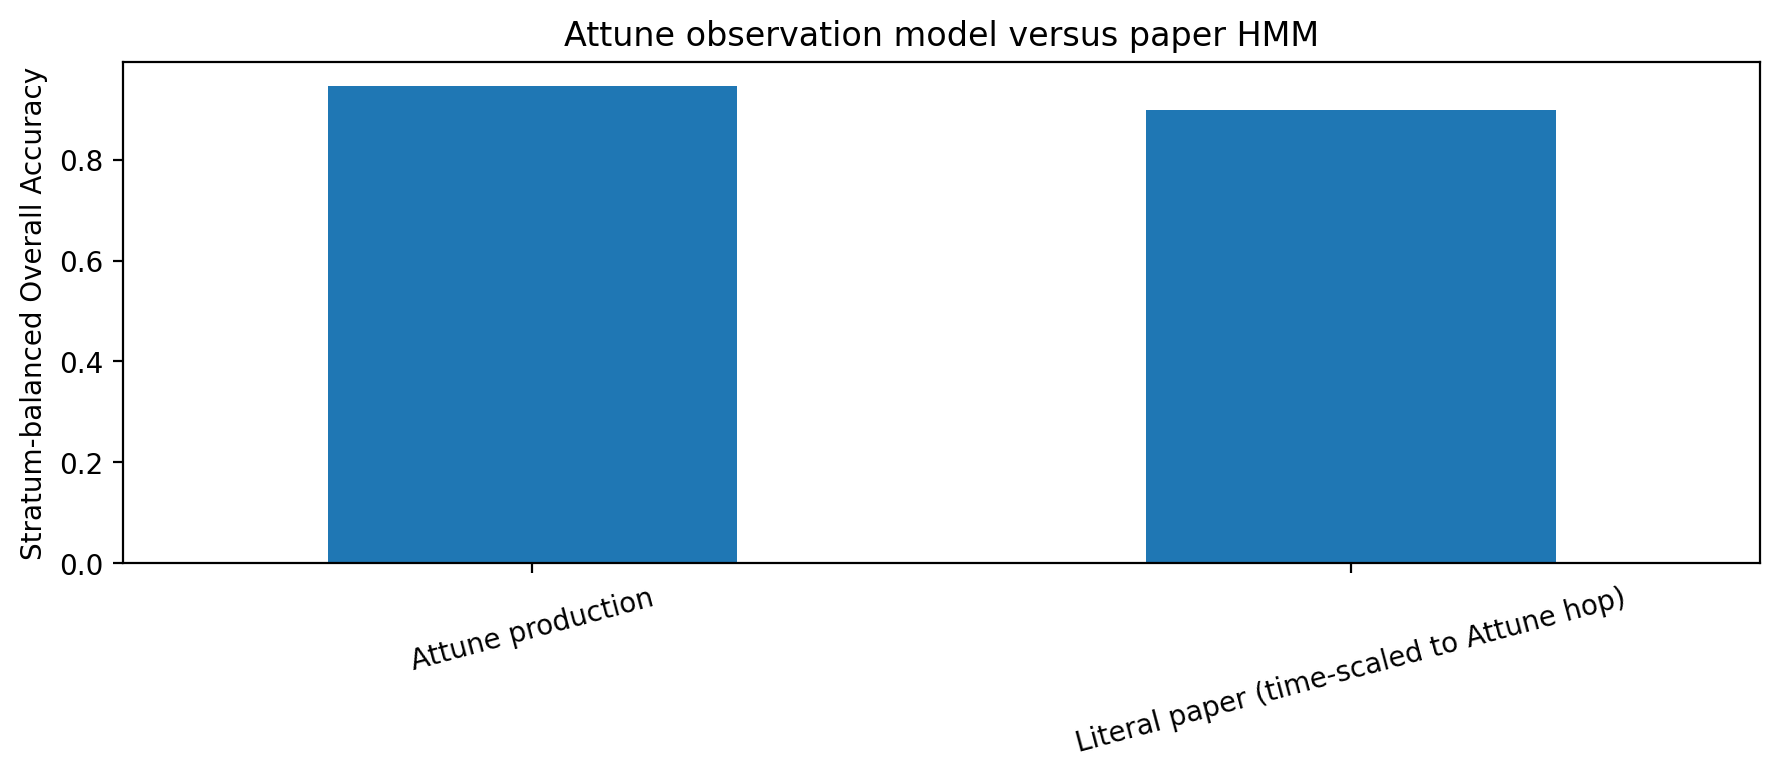

In [4]:
results = load_results(COMPACT_OUTPUT_DIR)
summary = results['summary']
recommendation = results['recommendation']
columns = [
    *PARAM_COLUMNS, 'Tracks', 'Errors',
    'Overall Accuracy', 'Raw Pitch Accuracy', 'Raw Chroma Accuracy',
    'Voicing Recall', 'Voicing False Alarm', 'voiced_fraction',
    'smoother_compute_time',
]

print('Automatic all-track winner (complete tuple):')
display(pd.DataFrame([{name: recommendation[name] for name in PARAM_COLUMNS}]))
print('Top all-track configurations:')
display(summary[columns].head(12))

named = {
    'Attune production': production_parameters(),
    'Literal paper (time-scaled to Attune hop)': paper_parameters(),
}
comparison_rows = []
for label, params in named.items():
    match = summary.copy()
    for name, value in params.items():
        match = match.loc[np.isclose(match[name], value) if isinstance(value, float) else match[name].eq(value)]
    if not match.empty:
        comparison_rows.append(match.assign(configuration=label))
comparison = pd.concat(comparison_rows, ignore_index=True)
display(comparison[['configuration', *columns]])

comparison.set_index('configuration')['Overall Accuracy'].plot.bar(figsize=(9, 4), rot=15)
plt.ylabel('Stratum-balanced Overall Accuracy')
plt.xlabel('')
plt.title('Attune observation model versus paper HMM')
plt.tight_layout()

## Regenerate raw pitch caches with the current YIN formulation

Run this cell before the dense sweep. It regenerates both raw and production-smoothed caches for the selected tracks in parallel. By default it skips caches already signed by the current Stage-1 detector; set `FORCE_CACHE_REFRESH = True` above to rebuild all selected caches.

In [5]:
cache_command = [
    sys.executable, str(CACHE_RUNNER),
    '--workers', str(WORKERS),
    '--output-dir', str(CACHE_REFRESH_OUTPUT_DIR),
    '--split', OPTIONS.split,
    '--seed', str(OPTIONS.seed),
    '--per-stratum', str(OPTIONS.per_stratum),
    '--tune-per-stratum', str(OPTIONS.tune_per_stratum),
]
if OPTIONS.max_strata is not None:
    cache_command += ['--max-strata', str(OPTIONS.max_strata)]
if OPTIONS.max_tracks is not None:
    cache_command += ['--max-tracks', str(OPTIONS.max_tracks)]
if FORCE_CACHE_REFRESH:
    cache_command.append('--force')

print(' '.join(cache_command))
subprocess.run(cache_command, cwd=REPO_ROOT, check=True)
display(pd.read_csv(CACHE_REFRESH_OUTPUT_DIR / 'cache_refresh.csv')['status'].value_counts())

/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python3 /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/scripts/regenerate_pitch_caches.py --workers 9 --output-dir /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch/cache_refresh --split test --seed 0 --per-stratum 2 --tune-per-stratum 1


Pitch-cache refresh: 0 stale/missing, 48 current; 9 worker processes
pitch caches: 0 regenerated, 48 already current, 0 errors


status
current    48
Name: count, dtype: int64

## Dense Attune-uniform sweep

This fixes the observation mode to `attune-uniform` and evaluates 8 maximum jumps × 4 switch probabilities × 7 YIN-trust values = 224 configurations. The launcher refuses to run if any selected raw cache is not signed by the current Stage-1 detector.

In [6]:
attune_grid = pd.DataFrame(parameter_grid(ATTUNE_AXES))
print(f'{len(sample)} stems × {len(attune_grid)} variants = {len(sample) * len(attune_grid):,} HMM evaluations')
display(attune_grid)

48 stems × 224 variants = 10,752 HMM evaluations


,observation_mode,max_jump_bins,switch_prob,yin_trust
0,attune-uniform,5,0.0025,0.25
1,attune-uniform,5,0.0025,0.35
2,attune-uniform,5,0.0025,0.45
3,attune-uniform,5,0.0025,0.50
4,attune-uniform,5,0.0025,0.55
...,...,...,...,...
219,attune-uniform,33,0.0200,0.45
220,attune-uniform,33,0.0200,0.50
221,attune-uniform,33,0.0200,0.55
222,attune-uniform,33,0.0200,0.65


In [7]:
command = sweep_command(ATTUNE_OUTPUT_DIR, ATTUNE_AXES, require_current_cache=True)
print(' '.join(command))
subprocess.run(command, cwd=REPO_ROOT, check=True)

/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python3 /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/scripts/pitch_hmm_param_sweep.py --workers 9 --output-dir /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch/attune_grid --split test --seed 0 --per-stratum 2 --tune-per-stratum 1 --observation-mode attune-uniform --max-jump-bins 5,9,13,17,21,25,29,33 --switch-prob 0.0025,0.005,0.01,0.02 --yin-trust 0.25,0.35,0.45,0.5,0.55,0.65,0.75 --require-current-cache


HMM sweep: 48 stems x 224 variants; 9 worker processes
results: /Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch/attune_grid


recommended parameters: {'observation_mode': 'attune-uniform', 'max_jump_bins': 9, 'switch_prob': 0.0025, 'yin_trust': 0.65}


CompletedProcess(args=['/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python3', '/Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/scripts/pitch_hmm_param_sweep.py', '--workers', '9', '--output-dir', '/Users/sarah/Desktop/shasha/Attune/benchmarks/sweeps/results/pitch/attune_grid', '--split', 'test', '--seed', '0', '--per-stratum', '2', '--tune-per-stratum', '1', '--observation-mode', 'attune-uniform', '--max-jump-bins', '5,9,13,17,21,25,29,33', '--switch-prob', '0.0025,0.005,0.01,0.02', '--yin-trust', '0.25,0.35,0.45,0.5,0.55,0.65,0.75', '--require-current-cache'], returncode=0)

In [8]:
attune_results = load_results(ATTUNE_OUTPUT_DIR)
attune_summary = attune_results['summary']
attune_recommendation = attune_results['recommendation']
winner = {name: attune_recommendation[name] for name in PARAM_COLUMNS}

print('Dense-grid all-track winner (complete tuple):')
display(pd.DataFrame([winner]))
print('Top 20 all-track configurations:')
display(attune_summary[columns].head(20))

comparison_rows = []
for label, params in {'Dense all-track winner': winner, 'Attune production': production_parameters()}.items():
    match = attune_summary.copy()
    for name, value in params.items():
        match = match.loc[np.isclose(match[name], value) if isinstance(value, float) else match[name].eq(value)]
    comparison_rows.append(match.assign(configuration=label))
dense_comparison = pd.concat(comparison_rows, ignore_index=True)
print('All-track winner versus production:')
display(dense_comparison[['configuration', *columns]])

for parameter in ('max_jump_bins', 'switch_prob', 'yin_trust'):
    marginal = attune_summary.groupby(parameter)['Overall Accuracy'].agg(['max', 'mean']).sort_values('max', ascending=False)
    print(parameter)
    display(marginal)

Dense-grid all-track winner (complete tuple):


,observation_mode,max_jump_bins,switch_prob,yin_trust
0,attune-uniform,9,0.0025,0.65


Top 20 all-track configurations:


,observation_mode,max_jump_bins,switch_prob,yin_trust,Tracks,Errors,Overall Accuracy,Raw Pitch Accuracy,Raw Chroma Accuracy,Voicing Recall,Voicing False Alarm,voiced_fraction,smoother_compute_time
0,attune-uniform,9,0.0025,0.65,48,0,0.946700,0.956728,0.958275,0.978130,0.216507,0.937879,1.146981
1,attune-uniform,29,0.0050,0.55,48,0,0.946690,0.956717,0.958739,0.979273,0.216396,0.938934,1.110098
2,attune-uniform,9,0.0100,0.55,48,0,0.946674,0.956413,0.958023,0.977882,0.212338,0.937369,1.134645
3,attune-uniform,9,0.0050,0.55,48,0,0.946672,0.956411,0.958021,0.977879,0.212338,0.937366,1.118691
4,attune-uniform,9,0.0025,0.55,48,0,0.946666,0.956399,0.958010,0.977865,0.212194,0.937346,1.142797
5,attune-uniform,17,0.0025,0.65,48,0,0.946663,0.956908,0.958896,0.979326,0.218895,0.939138,1.116107
6,attune-uniform,17,0.0050,0.65,48,0,0.946663,0.956908,0.958896,0.979326,0.218895,0.939138,1.103989
7,attune-uniform,9,0.0200,0.55,48,0,0.946656,0.956418,0.958028,0.977886,0.213046,0.937393,1.132742
8,attune-uniform,29,0.0100,0.55,48,0,0.946649,0.956711,0.958733,0.979267,0.217205,0.938963,1.109109
9,attune-uniform,9,0.0025,0.75,48,0,0.946598,0.956855,0.958387,0.978315,0.220286,0.938263,1.142468


All-track winner versus production:


...

,max,mean
max_jump_bins,,
9,0.946700,0.945878
29,0.946690,0.945929
17,0.946663,0.945961
13,0.946584,0.945919
33,0.946549,0.945951
25,0.946353,0.945727
21,0.946309,0.945702
5,0.945700,0.945404


switch_prob


,max,mean
switch_prob,,
0.0025,0.946700,0.945840
0.0050,0.946690,0.945828
0.0100,0.946674,0.945801
0.0200,0.946656,0.945765


yin_trust


,max,mean
yin_trust,,
0.65,0.946700,0.946193
0.55,0.946690,0.946316
0.75,0.946598,0.945986
0.50,0.946544,0.946118
0.45,0.946328,0.945953
0.35,0.945872,0.945484
0.25,0.945005,0.944612
